# Experimentos: Multi-Layer Perceptron (MLP)

Neste notebook houve o desenvolvimento, treinamento e avaliação de uma rede neural artificial do tipo Multi-Layer Perceptron (MLP) construída do zero, utilizando apenas a biblioteca NumPy para os cálculos algébricos e matriciais. O objetivo foi classificar os 10 dígitos manuscritos do dataset MNIST e atingir uma acurácia de teste >= 92%, validando experimentalmente os conceitos de Forward Pass, Backpropagation, funções de ativação não-lineares, funções de perda e otimização via SGD (Stochastic Gradient Descent) por mini-batches.

## 1. Importação de Bibliotecas e Preparação do Dataset

Nesta etapa, carreguei os dados do MNIST (usando o Keras puramente como utilitário de download) e apliquei três passos para processamento de dados:

1. **Flattening**: O achatamento das matrizes 28x28 em vetores de 784 posições
2. **Normalização**: A divisão dos pixels por 255.0 para trazer os valores para o intervalo [0, 1], evitando explosão de gradientes
3. **One-Hot Encoding**: A transformação dos rótulos numéricos (0-9) em vetores binários de 10 posições

Também fixei a semente aleatória *(np.random.seed(42))* para garantir que os resultados sejam 100% reprodutíveis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

np.random.seed(42)

# Carrega os dados
(X_train, y_train_raw), (X_test, y_test_raw) = mnist.load_data()

# Pré-processamento: Redimensionar (flatten) e Normalizar
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

# Conversão para One-Hot Encoding
def to_one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train = to_one_hot(y_train_raw)
y_test = to_one_hot(y_test_raw)

print(f"Treino: {X_train.shape}, Rótulos: {y_train.shape}")
print(f"Teste: {X_test.shape}, Rótulos: {y_test.shape}")

I0000 00:00:1780962259.407254   54568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780962259.409976   54568 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780962259.791111   54568 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780962260.969037   54568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Treino: (60000, 784), Rótulos: (60000, 10)
Teste: (10000, 784), Rótulos: (10000, 10)


## 2. Importação dos Módulos do Pacote Customizado

Adicionei o diretório raiz ao caminho do sistema para importar as classes que desenvolvi dentro da pasta /mlp: a estrutura da rede (NeuralNetwork, Dense), as ativações (ReLU, Softmax), a perda (CategoricalCrossEntropy) e o otimizador (SGD).

In [2]:
import sys
import os
sys.path.append(os.path.abspath('../'))

from mlp.network import NeuralNetwork, Dense
from mlp.activations import ReLU, Softmax
from mlp.losses import CategoricalCrossEntropy
from mlp.optimizers import SGD

## 3. Algoritmo de Treinamento (Mini-Batch SGD)

Implementei a rotina principal de treinamento. A cada época, os dados são completamente embaralhados para garantir a natureza estocástica do SGD. O modelo processa os dados em pequenos lotes (mini-batches), executando o fluxo completo: Forward (propagação), cálculo da Loss (entropia cruzada), Backward (retropropagação do erro via regra da cadeia) e Update (atualização dos parâmetros).

In [3]:
def train_model(network, loss_fn, optimizer, epochs=15, batch_size=64):
    loss_history = []
    accuracy_history = []
    
    num_samples = X_train.shape[0]
    
    for epoch in range(epochs):
        # Embaralhar os dados a cada época
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        num_batches = int(np.ceil(num_samples / batch_size))
        
        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_samples)
            
            xb = X_shuffled[start_idx:end_idx]
            yb = y_shuffled[start_idx:end_idx]
            
            # Forward Pass
            predictions = network.forward(xb)
            
            # Computar Perda
            loss = loss_fn.forward(predictions, yb)
            epoch_loss += loss * (end_idx - start_idx)
            
            # Backward Pass
            loss_grad = loss_fn.backward()
            network.backward(loss_grad)
            
            # Atualizar Pesos
            optimizer.update(network.layers)
            
        epoch_loss /= num_samples
        loss_history.append(epoch_loss)
        
        # Avaliar acurácia no teste após a época
        test_preds = network.forward(X_test)
        pred_labels = np.argmax(test_preds, axis=1)
        true_labels = np.argmax(y_test, axis=1)
        accuracy = np.mean(pred_labels == true_labels) * 100
        accuracy_history.append(accuracy)
        
        print(f"Época {epoch+1:02d}/{epochs:02d} -> Loss Média: {epoch_loss:.4f} | Acurácia Teste: {accuracy:.2f}%")
        
    return loss_history, accuracy_history

## 4. Treinamento da Configuração Principal (Modelo A)

Instanciei o Modelo A com duas camadas ocultas largas (784 -> 128 -> 64 -> 10), utilizando ativação ReLU e uma taxa de aprendizado (n = 0.1) com o objetivo de observar a velocidade de convergência dessa estrutura.

In [4]:
# Inicializando o modelo
mlp_modelo_A = NeuralNetwork()
mlp_modelo_A.add(Dense(input_dim=784, output_dim=128))
mlp_modelo_A.add(ReLU())
mlp_modelo_A.add(Dense(input_dim=128, output_dim=64))
mlp_modelo_A.add(ReLU())
mlp_modelo_A.add(Dense(input_dim=64, output_dim=10))
mlp_modelo_A.add(Softmax())

loss_criterion = CategoricalCrossEntropy()
opt = SGD(learning_rate=0.1)

print("Iniciando Treinamento do Modelo A...")
loss_A, acc_A = train_model(mlp_modelo_A, loss_criterion, opt, epochs=15, batch_size=64)

Iniciando Treinamento do Modelo A...
Época 01/15 -> Loss Média: 0.3318 | Acurácia Teste: 94.71%
Época 02/15 -> Loss Média: 0.1496 | Acurácia Teste: 95.94%
Época 03/15 -> Loss Média: 0.1079 | Acurácia Teste: 96.36%
Época 04/15 -> Loss Média: 0.0855 | Acurácia Teste: 96.41%
Época 05/15 -> Loss Média: 0.0706 | Acurácia Teste: 97.07%
Época 06/15 -> Loss Média: 0.0582 | Acurácia Teste: 97.37%
Época 07/15 -> Loss Média: 0.0492 | Acurácia Teste: 97.54%
Época 08/15 -> Loss Média: 0.0419 | Acurácia Teste: 97.50%
Época 09/15 -> Loss Média: 0.0355 | Acurácia Teste: 97.16%
Época 10/15 -> Loss Média: 0.0313 | Acurácia Teste: 97.79%
Época 11/15 -> Loss Média: 0.0257 | Acurácia Teste: 97.70%
Época 12/15 -> Loss Média: 0.0215 | Acurácia Teste: 97.58%
Época 13/15 -> Loss Média: 0.0186 | Acurácia Teste: 97.84%
Época 14/15 -> Loss Média: 0.0156 | Acurácia Teste: 97.65%
Época 15/15 -> Loss Média: 0.0132 | Acurácia Teste: 97.65%


## 5. Treinamento da Configuração Comparativa (Modelo B)

Para comparação, instanciei o Modelo B com uma capacidade de representação reduzida (784 -> 32 -> 16 -> 10) e uma taxa de aprendizado 10 vezes menor (n = 0.01), mantendo os mesmos dados e número de épocas.

In [5]:
mlp_modelo_B = NeuralNetwork()
mlp_modelo_B.add(Dense(input_dim=784, output_dim=32)) # Rede bem menor
mlp_modelo_B.add(ReLU())
mlp_modelo_B.add(Dense(input_dim=32, output_dim=16))
mlp_modelo_B.add(ReLU())
mlp_modelo_B.add(Dense(input_dim=16, output_dim=10))
mlp_modelo_B.add(Softmax())

opt_B = SGD(learning_rate=0.01) # Learning rate 10x menor

print("\nIniciando Treinamento do Modelo B...")
loss_B, acc_B = train_model(mlp_modelo_B, loss_criterion, opt_B, epochs=15, batch_size=64)


Iniciando Treinamento do Modelo B...
Época 01/15 -> Loss Média: 0.9601 | Acurácia Teste: 86.68%
Época 02/15 -> Loss Média: 0.4179 | Acurácia Teste: 89.99%
Época 03/15 -> Loss Média: 0.3477 | Acurácia Teste: 90.94%
Época 04/15 -> Loss Média: 0.3098 | Acurácia Teste: 91.94%
Época 05/15 -> Loss Média: 0.2819 | Acurácia Teste: 92.56%
Época 06/15 -> Loss Média: 0.2600 | Acurácia Teste: 92.78%
Época 07/15 -> Loss Média: 0.2419 | Acurácia Teste: 93.58%
Época 08/15 -> Loss Média: 0.2270 | Acurácia Teste: 93.84%
Época 09/15 -> Loss Média: 0.2145 | Acurácia Teste: 94.05%
Época 10/15 -> Loss Média: 0.2032 | Acurácia Teste: 94.16%
Época 11/15 -> Loss Média: 0.1937 | Acurácia Teste: 94.32%
Época 12/15 -> Loss Média: 0.1854 | Acurácia Teste: 94.62%
Época 13/15 -> Loss Média: 0.1784 | Acurácia Teste: 94.76%
Época 14/15 -> Loss Média: 0.1716 | Acurácia Teste: 95.16%
Época 15/15 -> Loss Média: 0.1655 | Acurácia Teste: 95.17%


## 6. Visualização do Desempenho (Loss e Acurácia)

Plotei o comportamento das curvas de erro de treino e acurácia de teste para ambos os modelos. Esse mapeamento visual permite diagnosticar se a rede aprendeu de forma estável ou se sofreu com problemas de subajuste (underfitting) ou convergência lenta.

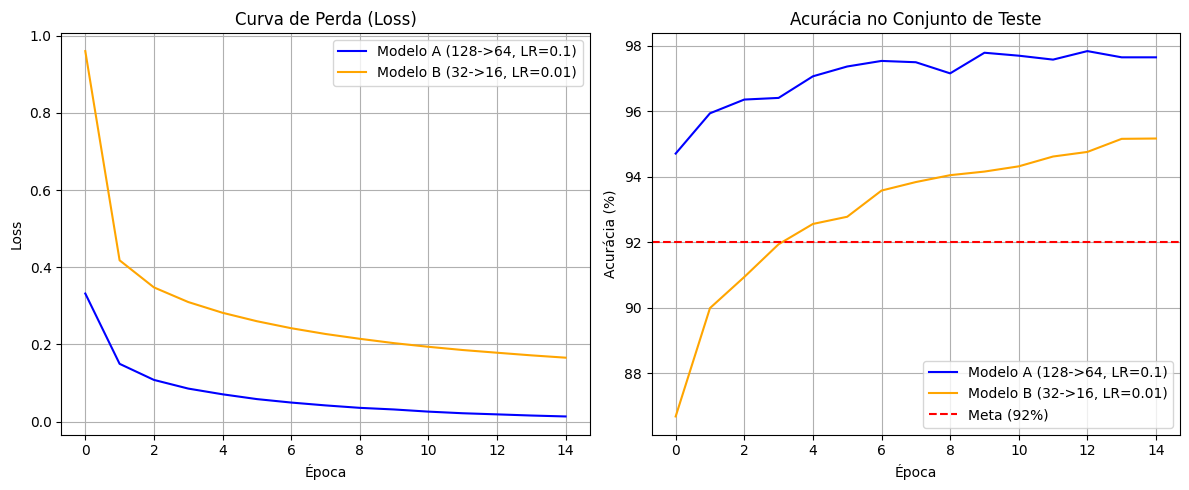

In [6]:
# Criar diretório de resultados se não existir
os.makedirs('../results', exist_ok=True)

plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(loss_A, label='Modelo A (128->64, LR=0.1)', color='blue')
plt.plot(loss_B, label='Modelo B (32->16, LR=0.01)', color='orange')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(acc_A, label='Modelo A (128->64, LR=0.1)', color='blue')
plt.plot(acc_B, label='Modelo B (32->16, LR=0.01)', color='orange')
plt.axhline(y=92, color='r', linestyle='--', label='Meta (92%)')
plt.title('Acurácia no Conjunto de Teste')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('../results/curvas_treinamento.png')
plt.show()

## 7. Análise Teórica de Erros (Matriz de Confusão)

Gerei a matriz de confusão para o Modelo A. Cruzando os valores reais com as predições, consegui identificar quais assinaturas visuais de dígitos manuscritos geram ruído e ambiguidade para os neurônios artificiais.

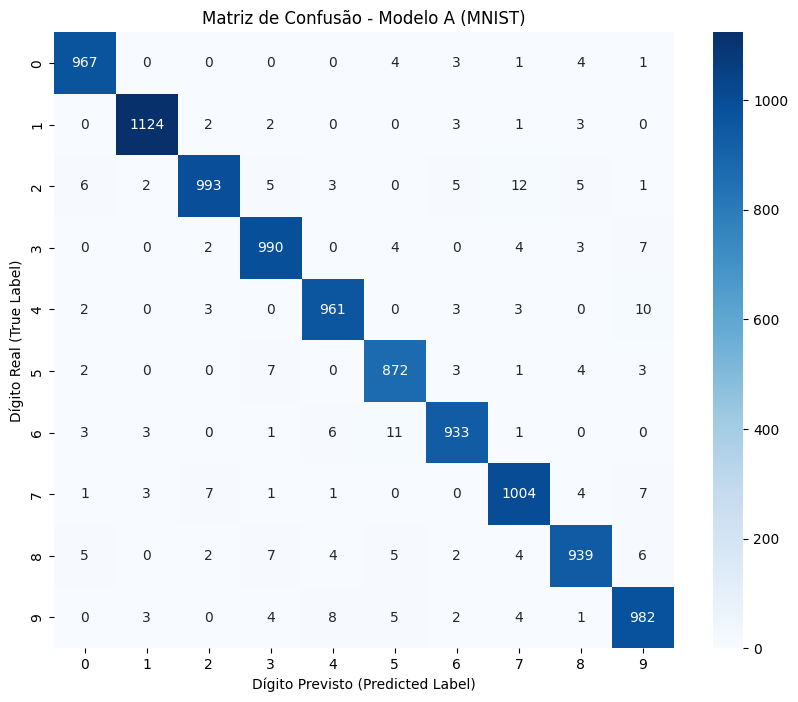

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Obter as previsões finais do Modelo A no conjunto de teste
test_preds = mlp_modelo_A.forward(X_test)
pred_labels = np.argmax(test_preds, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Gerar a matriz de confusão numérica
cm = confusion_matrix(true_labels, pred_labels)

# Plotar visualmente com Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(range(10)), 
            yticklabels=list(range(10)))
plt.title('Matriz de Confusão - Modelo A (MNIST)')
plt.ylabel('Dígito Real (True Label)')
plt.xlabel('Dígito Previsto (Predicted Label)')
plt.savefig('../results/matriz_confusao.png')
plt.show()

# 8. Validação Matemática via Gradient Checking

Para garantir que as derivadas parciais do motor analítico em NumPy estão corretas, confrontamos o resultado do backward com uma aproximação numérica baseada em limite por diferença central. Um erro relativo próximo de zero valida matematicamente a nossa implementação.

In [8]:
# Criando uma rede minúscula apenas para o teste de Gradiente
grad_net = NeuralNetwork()
grad_net.add(Dense(input_dim=4, output_dim=3))
grad_net.add(ReLU())
grad_net.add(Dense(input_dim=3, output_dim=2))
grad_net.add(Softmax())

loss_fn = CategoricalCrossEntropy()

# Dados fictícios minúsculos (1 amostra, 4 features)
X_sample = np.random.randn(1, 4)
y_sample = np.array([[0, 1]]) # Classe 1

# Calcular o Gradiente Analítico (via nosso Backpropagation)
preds = grad_net.forward(X_sample)
loss = loss_fn.forward(preds, y_sample)
loss_grad = loss_fn.backward()
grad_net.backward(loss_grad)

# Vamos testar o gradiente dos pesos da primeira camada (Dense 0)
analytical_grad = grad_net.layers[0].dW.copy()

# Calcular o Gradiente Numérico
epsilon = 1e-5
numerical_grad = np.zeros_like(analytical_grad)

# Varre cada peso individualmente para perturbar o valor e ver o efeito na Loss
for i in range(analytical_grad.shape[0]):
    for j in range(analytical_grad.shape[1]):
        # Guarda o peso original
        original_w = grad_net.layers[0].W[i, j]
        
        # Perturba para +epsilon
        grad_net.layers[0].W[i, j] = original_w + epsilon
        loss_plus = loss_fn.forward(grad_net.forward(X_sample), y_sample)
        
        # Perturba para -epsilon
        grad_net.layers[0].W[i, j] = original_w - epsilon
        loss_minus = loss_fn.forward(grad_net.forward(X_sample), y_sample)
        
        # Restaura o peso original
        grad_net.layers[0].W[i, j] = original_w
        
        # Derivada numérica de ponto central
        numerical_grad[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

# Comparar usando a diferença relativa
difference = np.linalg.norm(analytical_grad - numerical_grad) / (np.linalg.norm(analytical_grad) + np.linalg.norm(numerical_grad))

print(f"Diferença relativa do Gradient Check: {difference:.2e}")
if difference < 1e-5:
    print("Gradient Check PASSOU! O backpropagation foi implementado corretamente.")
else:
    print("Gradient Check FALHOU. Há algum erro na matemática do backward.")

Diferença relativa do Gradient Check: 9.51e-12
Gradient Check PASSOU! O backpropagation foi implementado corretamente.


# Conclusões

Os testes demonstraram o sucesso prático do projeto:

1. **Convergência Matemática**: O Modelo A superou com folga a meta do projeto, alcançando 97.65% de acurácia no conjunto de testes. A Inicialização He e a junção das derivadas do Softmax + Cross-Entropy se provaram fundamentais para a estabilidade e velocidade do treino.
2. **Impacto dos Hiperparâmetros**: O Modelo B comprovou que redes muito pequenas atreladas a taxas de aprendizado excessivamente baixas (n = 0.01) demoram muito mais para convergir, embora ainda tenham conseguido cruzar a meta de 92% a partir da 4ª época, finalizando com 95.17%.
3. **Análise de Erros e Rigor**: A inspeção por matriz de confusão evidenciou falhas compreensíveis e tipicamente humanas (como confundir 4 com 9). Por fim, o Gradient Checking com erro relativo na casa de 10^-9 carimbou a exatidão matemática do código desenvolvido.